# Analysis of the distance


In [1]:
import os 
import sys 
from base_fns import get_local_file
file = get_local_file()

local_dir = os.path.dirname(os.path.dirname(file))
sys.path.append(local_dir)

import json 
import dill 
import numpy as np 
import matplotlib.pyplot as plt
import numpy as np 

from config import Config
from tools.distance import DistanceTool 






## How to use ?

Please change the direction of the results you want to analyze 

In [2]:
# to change
path = 'tests'
number = 46
generation = 1
# end of to change

In [3]:
results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(number))
haploid_dir = os.path.join(results_dir, 'haploid')
diploid_dir = os.path.join(results_dir, 'diploid')

file = 'configs.json'
haploid_json_dir_file = os.path.join(haploid_dir, 'json', file)
diploid_json_dir_file = os.path.join(diploid_dir, 'json', file)

with open(haploid_json_dir_file, 'r') as f : 
    haploid_data_config = json.load(f)

with open(diploid_json_dir_file, 'r') as f : 
    diploid_data_config = json.load(f)

config = Config(haploid_data_config)
distance_tool = DistanceTool(config)

result = ''
for key, value in haploid_data_config.items():
    result += f'{key} : {value}\n'

diploid_result = ''
for key, value in diploid_data_config.items():
    diploid_result += f'{key} : {value}\n'

print(result)
print(diploid_result)

body_shape : [5, 5]
max_weight : 2
max_bias : 2
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 4
range_bias : 4
sigma_weight : 0.2
sigma_bias : 0.2
threshold_weight : 0.1
threshold_bias : 0.1
threshold_function : 0.1
threshold_dominance : 0.1
number_of_dominances : 5
generations : 40
population : 100
number_of_winner : 1
number_in_tournament : 5
number_of_elites : 2
shape_of_cppn : [10, 4, 4, 4, 2]
function_pool : ['gaussian', 'sin', 'tanh']
n_steps : 800
number_of_reported_individuals : 40
cpus : 30
env_name : ObstacleTraverser-v1

body_shape : [5, 5]
max_weight : 2
max_bias : 2
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 4
range_bias : 4
sigma_weight : 0.2
sigma_bias : 0.2
threshold_weight : 0.1
threshold_bias : 0.1
threshold_function : 0.1
threshold_dominance : 0.1
number_of_dominances : 5
generations : 40
population : 100
number_of_winner : 1
number_in_tournament : 5
number_of_elites : 2
shape_of_cppn : [10, 4, 4, 4, 2]
function_pool : [

# Haploid

In [4]:
pkl_dir = os.path.join(haploid_dir, 'pkl')
for file in os.listdir(pkl_dir) :
    if file.startswith('{}_cppn_registry.pkl'.format(generation)) :
        file_dir = os.path.join(pkl_dir, file)
        with open(file_dir, 'rb') as f :
            loaded_file_cppn = dill.load(f)

    if file.startswith('{}_body_registry.pkl'.format(generation)) :
        file_dir = os.path.join(pkl_dir, file)
        with open(file_dir, 'rb') as f :
            loaded_file_body = dill.load(f)

    if file.startswith('{}_controller_network_registry.pkl'.format(generation)) :
        file_dir = os.path.join(pkl_dir, file)
        with open(file_dir, 'rb') as f :
            loaded_file_controller = dill.load(f)

In [5]:
list_of_keys_cppn = list(loaded_file_cppn.keys())
list_of_keys_body = list(loaded_file_body.keys())
list_of_keys_controller = list(loaded_file_controller.keys())
# should be the same but put this way f0ro readable


count = 0 
act_function_distances = []
weight_distances = []
bias_distances = []
distances = []
controller_distances = []
compatibilities = []
normalized_act_function_distances = []
normalized_weight_distances = []
normalized_bias_distances = []
normalized_controller_distances = []


for i in range(len(list_of_keys_cppn)) : 
    for j in range(i+1, len(list_of_keys_cppn)) : 
        generation1, id_cppn1 = list_of_keys_cppn[i]
        generation2, id_cppn2 = list_of_keys_cppn[j]

        generation1_body, id_body1 = list_of_keys_body[i]
        generation2_body, id_body2 = list_of_keys_body[j]

        generation1_controller, id_controller1 = list_of_keys_controller[i]
        generation2_controller, id_controller2 = list_of_keys_controller[j]

        node_evals1 = loaded_file_cppn[(generation1, id_cppn1)].node_evals
        node_evals2 = loaded_file_cppn[(generation2, id_cppn2)].node_evals
        # here also same generation 
        body1 = loaded_file_body[(generation1_body, id_body1)].body
        body2 = loaded_file_body[(generation2_body, id_body2)].body 

        controller_node_evals1 = loaded_file_controller[(generation1_controller, id_controller1)].node_evals
        controller_node_evals2 = loaded_file_controller[(generation2_controller, id_controller2)].node_evals

        act_function_distance, weight_distance, bias_distance, normalized_act_function_distance, normalized_weight_distance, normalized_bias_distance = distance_tool.distance_expressed_genome(node_evals1, node_evals2)
        distance, distance_normalized = distance_tool.phenotypic_body_distance(body1, body2)
        controller_distance, normalized_controller_distance = distance_tool.phenotypic_controller_distance(controller_node_evals1, controller_node_evals2)

        act_function_distances.append(act_function_distance)
        weight_distances.append(weight_distance)
        bias_distances.append(bias_distance)
        distances.append(distance)
        controller_distances.append(controller_distance)
        compatibilities.append(100 * (1 - distance_normalized))
        normalized_act_function_distances.append(normalized_act_function_distance)
        normalized_weight_distances.append(normalized_weight_distance)
        normalized_bias_distances.append(normalized_bias_distance)
        normalized_controller_distances.append(normalized_controller_distance)

        count += 1

print('Number of comparisons : {}'.format(count))
average_act_function_distance = np.mean(np.array(act_function_distances))
average_weight_distance = np.mean(np.array(weight_distances))
average_bias_distance = np.mean(np.array(bias_distances))
average_distance = np.mean(np.array(distances))
average_controller_distance = np.mean(np.array(controller_distances))
average_compatibility = np.mean(np.array(compatibilities))
average_normalized_act_function_distance = np.mean(np.array(normalized_act_function_distances))
average_normalized_weight_distance = np.mean(np.array(normalized_weight_distances))
average_normalized_bias_distance = np.mean(np.array(normalized_bias_distances))
average_normalized_controller_distance = np.mean(np.array(normalized_controller_distances))


print('Average distance between the activation functions of the CPPNs : {}'.format(average_act_function_distance))
print('Average distance between the weights of the CPPNs : {}'.format(average_weight_distance)) 
print('Average distance between the biases of the CPPNs : {}'.format(average_bias_distance))
print('Average normalized distance between the activation functions of the CPPNs : {}'.format(average_normalized_act_function_distance))
print('Average normalized distance between the weights of the CPPNs : {}'.format(average_normalized_weight_distance))
print('Average normalized distance between the biases of the CPPNs : {}'.format(average_normalized_bias_distance))
print('Average distance between the bodies : {}'.format(average_distance))
print('Average compatibility of the bodies : {}'.format(average_compatibility))
print('Average distance between the controllers : {}'.format(average_controller_distance))
print('Average normalized distance between the controllers : {}'.format(average_normalized_controller_distance))
        


    





Number of comparisons : 2556
Average distance between the activation functions of the CPPNs : 8.02073552425665
Average distance between the weights of the CPPNs : 211.49331088122693
Average distance between the biases of the CPPNs : 36.599617235004594
Average normalized distance between the activation functions of the CPPNs : 0.5729096803040465
Average normalized distance between the weights of the CPPNs : 0.3304582982519171
Average normalized distance between the biases of the CPPNs : 0.3267822967411125
Average distance between the bodies : 13.408255086071987
Average compatibility of the bodies : 46.36697965571205
Average distance between the controllers : 5595.080735198574
Average normalized distance between the controllers : 0.23089737617155465


## Study with graph 


In [6]:
generation = 1
generations = []

average_list_distance_functions = []
average_list_distance_weights = []
average_list_distance_biases = []
average_list_distance_bodies = []
average_list_distance_controllers = []
average_list_normalized_distance_bodies = []
average_list_compatibility = []
average_list_normalized_activation_function_distance = []
average_list_normalized_weight_distance = []
average_list_normalized_bias_distance = []
average_list_normalized_controller_distance = []

std_list_distance_functions = []
std_list_distance_weights = []
std_list_distance_biases = []
std_list_distance_bodies = []
std_list_distance_controllers = []
std_list_normalized_distance_bodies = []
std_list_compatibility = []
std_list_normalized_activation_function_distance = []
std_list_normalized_weight_distance = []
std_list_normalized_bias_distance = []
std_list_normalized_controller_distance = []



while True :

    cppn = [f for f in os.listdir(pkl_dir) if f.startswith('{}_cppn_registry.pkl'.format(generation))]
    body = [f for f in os.listdir(pkl_dir) if f.startswith('{}_body_registry.pkl'.format(generation))]
    controller = [f for f in os.listdir(pkl_dir) if f.startswith('{}_controller_network_registry.pkl'.format(generation))]

    if not cppn or not body or not controller :
        break

    file_dir = os.path.join(pkl_dir, cppn[0])
    with open(file_dir, 'rb') as f :
        loaded_file_cppn = dill.load(f)

    file_dir = os.path.join(pkl_dir, body[0])
    with open(file_dir, 'rb') as f :
        loaded_file_body = dill.load(f)

    file_dir = os.path.join(pkl_dir, controller[0])
    with open(file_dir, 'rb') as f :
        loaded_file_controller = dill.load(f)

    list_of_keys_cppn = list(loaded_file_cppn.keys())
    list_of_keys_body = list(loaded_file_body.keys())
    list_of_keys_controller = list(loaded_file_controller.keys())

    act_function_distances = []
    weight_distances = []
    bias_distances = []
    distances = []
    controller_distances = []
    normalized_distance_bodys = []
    compatibilities = []
    normalized_act_function_distances = []
    normalized_weight_distances = []
    normalized_bias_distances = []
    normalized_controller_distances = []

    for i in range(len(list_of_keys_cppn)) :
        for j in range(i+1, len(list_of_keys_cppn)) : 
            generation1, id_cppn1 = list_of_keys_cppn[i]
            generation2, id_cppn2 = list_of_keys_cppn[j]

            generation1_body, id_body1 = list_of_keys_body[i]
            generation2_body, id_body2 = list_of_keys_body[j]

            generation1_controller, id_controller1 = list_of_keys_controller[i]
            generation2_controller, id_controller2 = list_of_keys_controller[j]

            node_evals1 = loaded_file_cppn[(generation1, id_cppn1)].node_evals
            node_evals2 = loaded_file_cppn[(generation2, id_cppn2)].node_evals
            # here also same generation 
            body1 = loaded_file_body[(generation1_body, id_body1)].body
            body2 = loaded_file_body[(generation2_body, id_body2)].body 

            controller_node_evals1 = loaded_file_controller[(generation1_controller, id_controller1)].node_evals
            controller_node_evals2 = loaded_file_controller[(generation2_controller, id_controller2)].node_evals

            act_function_distance, weight_distance, bias_distance, normalized_act_function_distance, normalized_weight_distance, normalized_bias_distance = distance_tool.distance_expressed_genome(node_evals1, node_evals2)
            distance, distance_normalized = distance_tool.phenotypic_body_distance(body1, body2)
            controller_distance, normalized_controller_distance = distance_tool.phenotypic_controller_distance(controller_node_evals1, controller_node_evals2)

            act_function_distances.append(act_function_distance)
            weight_distances.append(weight_distance)
            bias_distances.append(bias_distance)
            distances.append(distance)
            controller_distances.append(controller_distance)
            normalized_distance_bodys.append(distance_normalized)
            compatibilities.append(100 * (1 - distance_normalized))
            normalized_act_function_distances.append(normalized_act_function_distance)
            normalized_weight_distances.append(normalized_weight_distance)
            normalized_bias_distances.append(normalized_bias_distance)
            normalized_controller_distances.append(normalized_controller_distance)

    average_act_function_distance = np.mean(np.array(act_function_distances))
    average_weight_distance = np.mean(np.array(weight_distances))
    average_bias_distance = np.mean(np.array(bias_distances))    
    average_distance = np.mean(np.array(distances))
    average_controller_distance = np.mean(np.array(controller_distances))
    average_normalized_distance_body = np.mean(np.array(normalized_distance_bodys))
    average_compatibility = np.mean(np.array(compatibilities))
    average_normalized_act_function_distance = np.mean(np.array(normalized_act_function_distances))
    average_normalized_weight_distance = np.mean(np.array(normalized_weight_distances))
    average_normalized_bias_distance = np.mean(np.array(normalized_bias_distances))
    average_normalized_controller_distance = np.mean(np.array(normalized_controller_distances))

    std_act_function_distance = np.std(np.array(act_function_distances))
    std_weight_distance = np.std(np.array(weight_distances))
    std_bias_distance = np.std(np.array(bias_distances))
    std_distance = np.std(np.array(distances))
    std_controller_distance = np.std(np.array(controller_distances))
    std_normalized_distance_body = np.std(np.array(normalized_distance_bodys))
    std_compatibility = np.std(np.array(compatibilities))
    std_normalized_act_function_distance = np.std(np.array(normalized_act_function_distances))
    std_normalized_weight_distance = np.std(np.array(normalized_weight_distances))
    std_normalized_bias_distance = np.std(np.array(normalized_bias_distances))
    std_normalized_controller_distance = np.std(np.array(normalized_controller_distances))

    average_list_distance_functions.append(average_act_function_distance)
    average_list_distance_weights.append(average_weight_distance)
    average_list_distance_biases.append(average_bias_distance)    
    average_list_distance_bodies.append(average_distance)
    average_list_distance_controllers.append(average_controller_distance)
    average_list_normalized_distance_bodies.append(average_normalized_distance_body)
    average_list_compatibility.append(average_compatibility)    
    average_list_normalized_activation_function_distance.append(average_normalized_act_function_distance)
    average_list_normalized_weight_distance.append(average_normalized_weight_distance)
    average_list_normalized_bias_distance.append(average_normalized_bias_distance)
    average_list_normalized_controller_distance.append(average_normalized_controller_distance)

    std_list_distance_functions.append(std_act_function_distance)
    std_list_distance_weights.append(std_weight_distance)
    std_list_distance_biases.append(std_bias_distance)
    std_list_distance_bodies.append(std_distance)
    std_list_distance_controllers.append(std_controller_distance)
    std_list_normalized_distance_bodies.append(std_normalized_distance_body)
    std_list_compatibility.append(std_compatibility)
    std_list_normalized_activation_function_distance.append(std_normalized_act_function_distance)
    std_list_normalized_weight_distance.append(std_normalized_weight_distance)
    std_list_normalized_bias_distance.append(std_normalized_bias_distance)
    std_list_normalized_controller_distance.append(std_normalized_controller_distance)


    generations.append(generation)
    generation += 1


KeyboardInterrupt: 

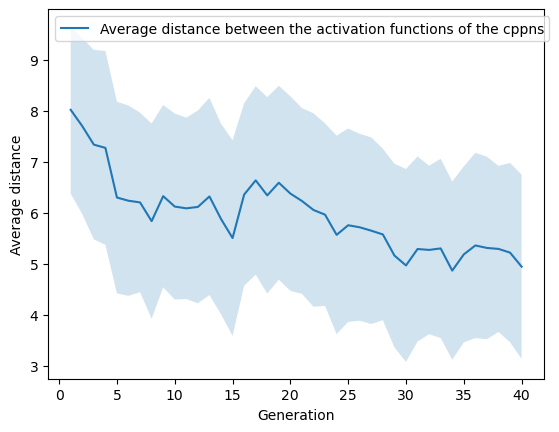

In [ ]:
fig = plt.figure()
plt.plot(generations, average_list_distance_functions, label = 'Average distance between the activation functions of the cppns')
plt.fill_between(generations, np.array(average_list_distance_functions) - np.array(std_list_distance_functions), np.array(average_list_distance_functions) + np.array(std_list_distance_functions), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')
plt.legend(loc = 'upper left')
plt.show()

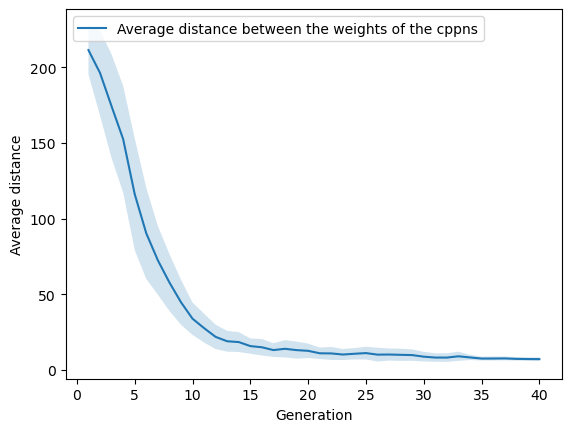

In [ ]:
plt.figure()
plt.plot(generations, average_list_distance_weights, label = 'Average distance between the weights of the cppns')
plt.fill_between(generations, np.array(average_list_distance_weights) - np.array(std_list_distance_weights), np.array(average_list_distance_weights) + np.array(std_list_distance_weights), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')
plt.legend(loc = 'upper left')
plt.show()

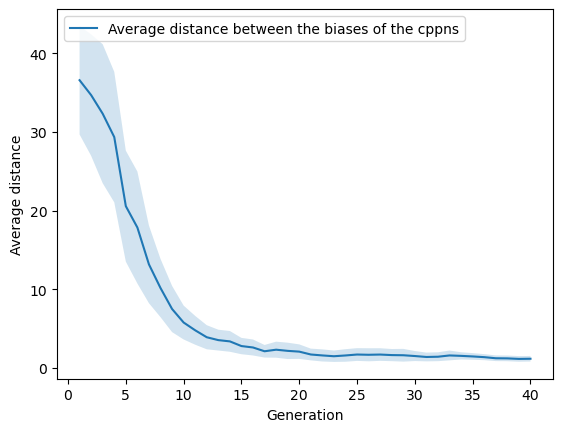

In [ ]:
plt.Figure()
plt.plot(generations, average_list_distance_biases, label = 'Average distance between the biases of the cppns')
plt.fill_between(generations, np.array(average_list_distance_biases) - np.array(std_list_distance_biases), np.array(average_list_distance_biases) + np.array(std_list_distance_biases), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')    
plt.legend(loc = 'upper left')
plt.show()

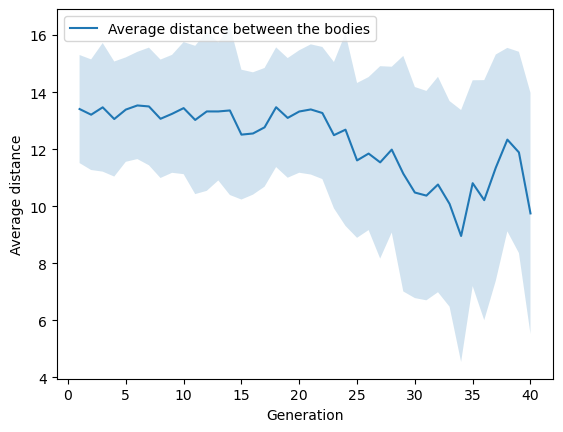

In [ ]:
plt.figure()
plt.plot(generations, average_list_distance_bodies, label = 'Average distance between the bodies')
plt.fill_between(generations, np.array(average_list_distance_bodies) - np.array(std_list_distance_bodies), np.array(average_list_distance_bodies) + np.array(std_list_distance_bodies), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')
plt.legend(loc = 'upper left')
plt.show()

In [ ]:
plt.figure()
plt.plot(generations, average_list_distance_controllers, label = 'Average distance between the controllers')
plt.fill_between(generations, np.array(average_list_distance_controllers) - np.array(std_list_distance_controllers), np.array(average_list_distance_controllers) + np.array(std_list_distance_controllers), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')
plt.legend(loc = 'upper left')
plt.show()

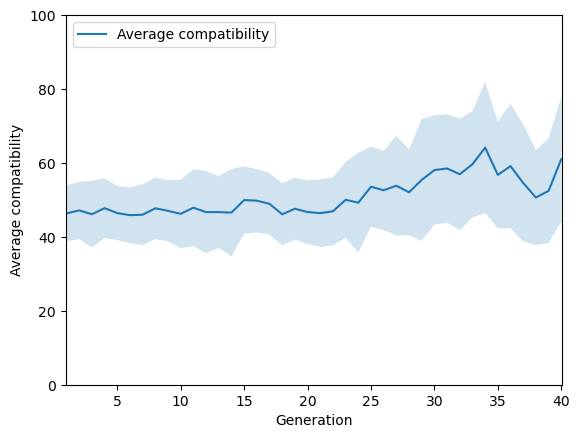

In [ ]:
plt.figure()
plt.plot(generations, average_list_compatibility, label = 'Average compatibility')
plt.fill_between(generations, np.array(average_list_compatibility) - np.array(std_list_compatibility), np.array(average_list_compatibility) + np.array(std_list_compatibility), alpha = 0.2)
plt.axis([0.95, generations[-1] + 0.05, 0, 100])
plt.xlabel('Generation')
plt.ylabel('Average compatibility')
plt.legend(loc = 'upper left')
plt.show()

In [ ]:
plt.figure()
plt.plot(generations, average_list_normalized_activation_function_distance, label = 'Average normalized distance between the activation functions of the cppns')
plt.plot(generations, average_list_normalized_weight_distance, label = 'Average normalized distance between the weights of the cppns')
plt.plot(generations, average_list_normalized_bias_distance, label = 'Average normalized distance between the biases of the cppns')
plt.plot(generations, average_list_normalized_distance_bodies, label = 'Average normalized distance between the bodies')
plt.plot(generations, average_list_normalized_controller_distance, label = 'Average normalized distance between the controllers')
plt.fill_between(generations, np.array(average_list_normalized_activation_function_distance) - np.array(std_list_normalized_activation_function_distance), np.array(average_list_normalized_activation_function_distance) + np.array(std_list_normalized_activation_function_distance), alpha = 0.2)
plt.fill_between(generations, np.array(average_list_normalized_weight_distance) - np.array(std_list_normalized_weight_distance), np.array(average_list_normalized_weight_distance) + np.array(std_list_normalized_weight_distance), alpha = 0.2)
plt.fill_between(generations, np.array(average_list_normalized_bias_distance) - np.array(std_list_normalized_bias_distance), np.array(average_list_normalized_bias_distance) + np.array(std_list_normalized_bias_distance), alpha = 0.2)
plt.fill_between(generations, np.array(average_list_normalized_distance_bodies) - np.array(std_list_normalized_distance_bodies), np.array(average_list_normalized_distance_bodies) + np.array(std_list_normalized_distance_bodies), alpha = 0.2)
plt.fill_between(generations, np.array(average_list_normalized_controller_distance) - np.array(std_list_normalized_controller_distance), np.array(average_list_normalized_controller_distance) + np.array(std_list_normalized_controller_distance), alpha = 0.2)
plt.axis([0.95, generations[-1] + 0.05, 0, 1.2])
plt.xlabel('Generations')
plt.ylabel('Normalized distance')
plt.legend(loc = 'upper left')
plt.show()

# Diploid

In [ ]:
generation = 1
pkl_dir = os.path.join(diploid_dir, 'pkl')
for file in os.listdir(pkl_dir) :
    if file.startswith('{}_cppn_registry.pkl'.format(generation)) :
        file_dir = os.path.join(pkl_dir, file)
        with open(file_dir, 'rb') as f :
            loaded_file_cppn = dill.load(f)

    if file.startswith('{}_body_registry.pkl'.format(generation)) :
        file_dir = os.path.join(pkl_dir, file)
        with open(file_dir, 'rb') as f :
            loaded_file_body = dill.load(f)

    if file.startswith('{}_controller_network_registry.pkl'.format(generation)) :
        file_dir = os.path.join(pkl_dir, file)
        with open(file_dir, 'rb') as f :
            loaded_file_controller = dill.load(f)

In [ ]:
list_of_keys_cppn = list(loaded_file_cppn.keys())
list_of_keys_body = list(loaded_file_body.keys())
list_of_keys_controller = list(loaded_file_controller.keys())
# should be the same but put this way f0ro readable


count = 0 
act_function_distances = []
weight_distances = []
bias_distances = []
distances = []
controller_distances = []
compatibilities = []
normalized_act_function_distances = []
normalized_weight_distances = []
normalized_bias_distances = []
normalized_controller_distances = []


for i in range(len(list_of_keys_cppn)) : 
    for j in range(i+1, len(list_of_keys_cppn)) : 
        generation1, id_cppn1 = list_of_keys_cppn[i]
        generation2, id_cppn2 = list_of_keys_cppn[j]

        generation1_body, id_body1 = list_of_keys_body[i]
        generation2_body, id_body2 = list_of_keys_body[j]

        generation1_controller, id_controller1 = list_of_keys_controller[i]
        generation2_controller, id_controller2 = list_of_keys_controller[j]

        node_evals1 = loaded_file_cppn[(generation1, id_cppn1)].node_evals
        node_evals2 = loaded_file_cppn[(generation2, id_cppn2)].node_evals
        # here also same generation 
        body1 = loaded_file_body[(generation1_body, id_body1)].body
        body2 = loaded_file_body[(generation2_body, id_body2)].body 

        controller_node_evals1 = loaded_file_controller[(generation1_controller, id_controller1)].node_evals
        controller_node_evals2 = loaded_file_controller[(generation2_controller, id_controller2)].node_evals

        act_function_distance, weight_distance, bias_distance, normalized_act_function_distance, normalized_weight_distance, normalized_bias_distance = distance_tool.distance_expressed_genome(node_evals1, node_evals2)
        distance, distance_normalized = distance_tool.phenotypic_body_distance(body1, body2)
        controller_distance, normalized_controller_distance = distance_tool.phenotypic_controller_distance(controller_node_evals1, controller_node_evals2)

        act_function_distances.append(act_function_distance)
        weight_distances.append(weight_distance)
        bias_distances.append(bias_distance)
        distances.append(distance)
        controller_distances.append(controller_distance)
        compatibilities.append(100 * (1 - distance_normalized))
        normalized_act_function_distances.append(normalized_act_function_distance)
        normalized_weight_distances.append(normalized_weight_distance)
        normalized_bias_distances.append(normalized_bias_distance)
        normalized_controller_distances.append(normalized_controller_distance)

        count += 1

print('Number of comparisons : {}'.format(count))
average_act_function_distance = np.mean(np.array(act_function_distances))
average_weight_distance = np.mean(np.array(weight_distances))
average_bias_distance = np.mean(np.array(bias_distances))
average_distance = np.mean(np.array(distances))
average_controller_distance = np.mean(np.array(controller_distances))
average_compatibility = np.mean(np.array(compatibilities))
average_normalized_act_function_distance = np.mean(np.array(normalized_act_function_distances))
average_normalized_weight_distance = np.mean(np.array(normalized_weight_distances))
average_normalized_bias_distance = np.mean(np.array(normalized_bias_distances))
average_normalized_controller_distance = np.mean(np.array(normalized_controller_distances))


print('Average distance between the activation functions of the CPPNs : {}'.format(average_act_function_distance))
print('Average distance between the weights of the CPPNs : {}'.format(average_weight_distance)) 
print('Average distance between the biases of the CPPNs : {}'.format(average_bias_distance))
print('Average normalized distance between the activation functions of the CPPNs : {}'.format(average_normalized_act_function_distance))
print('Average normalized distance between the weights of the CPPNs : {}'.format(average_normalized_weight_distance))
print('Average normalized distance between the biases of the CPPNs : {}'.format(average_normalized_bias_distance))
print('Average distance between the bodies : {}'.format(average_distance))
print('Average compatibility of the bodies : {}'.format(average_compatibility))
print('Average distance between the controllers : {}'.format(average_controller_distance))
print('Average normalized distance between the controllers : {}'.format(average_normalized_controller_distance))

## Study with graph 


In [ ]:
generation = 1
diploid_generations = []

diploid_average_list_distance_functions = []
diploid_average_list_distance_weights = []
diploid_average_list_distance_biases = []
diploid_average_list_distance_bodies = []
diploid_average_list_distance_controllers = []
diploid_average_list_normalized_distance_bodies = []
diploid_average_list_compatibility = []
diploid_average_list_normalized_activation_function_distance = []
diploid_average_list_normalized_weight_distance = []
diploid_average_list_normalized_bias_distance = []
diploid_average_list_normalized_controller_distance = []

diploid_std_list_distance_functions = []
diploid_std_list_distance_weights = []
diploid_std_list_distance_biases = []
diploid_std_list_distance_bodies = []
diploid_std_list_distance_controllers = []
diploid_std_list_normalized_distance_bodies = []
diploid_std_list_compatibility = []
diploid_std_list_normalized_activation_function_distance = []
diploid_std_list_normalized_weight_distance = []
diploid_std_list_normalized_bias_distance = []
diploid_std_list_normalized_controller_distance = []



while True :

    cppn = [f for f in os.listdir(pkl_dir) if f.startswith('{}_cppn_registry.pkl'.format(generation))]
    body = [f for f in os.listdir(pkl_dir) if f.startswith('{}_body_registry.pkl'.format(generation))]
    controller = [f for f in os.listdir(pkl_dir) if f.startswith('{}_controller_network_registry.pkl'.format(generation))]

    if not cppn or not body or not controller :
        break

    file_dir = os.path.join(pkl_dir, cppn[0])
    with open(file_dir, 'rb') as f :
        loaded_file_cppn = dill.load(f)

    file_dir = os.path.join(pkl_dir, body[0])
    with open(file_dir, 'rb') as f :
        loaded_file_body = dill.load(f)

    file_dir = os.path.join(pkl_dir, controller[0])
    with open(file_dir, 'rb') as f :
        loaded_file_controller = dill.load(f)

    list_of_keys_cppn = list(loaded_file_cppn.keys())
    list_of_keys_body = list(loaded_file_body.keys())
    list_of_keys_controller = list(loaded_file_controller.keys())

    act_function_distances = []
    weight_distances = []
    bias_distances = []
    distances = []
    controller_distances = []
    normalized_distance_bodys = []
    compatibilities = []
    normalized_act_function_distances = []
    normalized_weight_distances = []
    normalized_bias_distances = []
    normalized_controller_distances = []

    for i in range(len(list_of_keys_cppn)) :
        for j in range(i+1, len(list_of_keys_cppn)) : 
            generation1, id_cppn1 = list_of_keys_cppn[i]
            generation2, id_cppn2 = list_of_keys_cppn[j]

            generation1_body, id_body1 = list_of_keys_body[i]
            generation2_body, id_body2 = list_of_keys_body[j]

            generation1_controller, id_controller1 = list_of_keys_controller[i]
            generation2_controller, id_controller2 = list_of_keys_controller[j]

            node_evals1 = loaded_file_cppn[(generation1, id_cppn1)].node_evals
            node_evals2 = loaded_file_cppn[(generation2, id_cppn2)].node_evals
            # here also same generation 
            body1 = loaded_file_body[(generation1_body, id_body1)].body
            body2 = loaded_file_body[(generation2_body, id_body2)].body 

            controller_node_evals1 = loaded_file_controller[(generation1_controller, id_controller1)].node_evals
            controller_node_evals2 = loaded_file_controller[(generation2_controller, id_controller2)].node_evals

            act_function_distance, weight_distance, bias_distance, normalized_act_function_distance, normalized_weight_distance, normalized_bias_distance = distance_tool.distance_expressed_genome(node_evals1, node_evals2)
            distance, distance_normalized = distance_tool.phenotypic_body_distance(body1, body2)
            controller_distance, normalized_controller_distance = distance_tool.phenotypic_controller_distance(controller_node_evals1, controller_node_evals2)

            act_function_distances.append(act_function_distance)
            weight_distances.append(weight_distance)
            bias_distances.append(bias_distance)
            distances.append(distance)
            controller_distances.append(controller_distance)
            normalized_distance_bodys.append(distance_normalized)
            compatibilities.append(100 * (1 - distance_normalized))
            normalized_act_function_distances.append(normalized_act_function_distance)
            normalized_weight_distances.append(normalized_weight_distance)
            normalized_bias_distances.append(normalized_bias_distance)
            normalized_controller_distances.append(normalized_controller_distance)

    average_act_function_distance = np.mean(np.array(act_function_distances))
    average_weight_distance = np.mean(np.array(weight_distances))
    average_bias_distance = np.mean(np.array(bias_distances))    
    average_distance = np.mean(np.array(distances))
    average_controller_distance = np.mean(np.array(controller_distances))
    average_normalized_distance_body = np.mean(np.array(normalized_distance_bodys))
    average_compatibility = np.mean(np.array(compatibilities))
    average_normalized_act_function_distance = np.mean(np.array(normalized_act_function_distances))
    average_normalized_weight_distance = np.mean(np.array(normalized_weight_distances))
    average_normalized_bias_distance = np.mean(np.array(normalized_bias_distances))
    average_normalized_controller_distance = np.mean(np.array(normalized_controller_distances))

    std_act_function_distance = np.std(np.array(act_function_distances))
    std_weight_distance = np.std(np.array(weight_distances))
    std_bias_distance = np.std(np.array(bias_distances))
    std_distance = np.std(np.array(distances))
    std_controller_distance = np.std(np.array(controller_distances))
    std_normalized_distance_body = np.std(np.array(normalized_distance_bodys))
    std_compatibility = np.std(np.array(compatibilities))
    std_normalized_act_function_distance = np.std(np.array(normalized_act_function_distances))
    std_normalized_weight_distance = np.std(np.array(normalized_weight_distances))
    std_normalized_bias_distance = np.std(np.array(normalized_bias_distances))
    std_normalized_controller_distance = np.std(np.array(normalized_controller_distances))

    diploid_average_list_distance_functions.append(average_act_function_distance)
    diploid_average_list_distance_weights.append(average_weight_distance)
    diploid_average_list_distance_biases.append(average_bias_distance)    
    diploid_average_list_distance_bodies.append(average_distance)
    diploid_average_list_distance_controllers.append(average_controller_distance)
    diploid_average_list_normalized_distance_bodies.append(average_normalized_distance_body)
    diploid_average_list_compatibility.append(average_compatibility)    
    diploid_average_list_normalized_activation_function_distance.append(average_normalized_act_function_distance)
    diploid_average_list_normalized_weight_distance.append(average_normalized_weight_distance)
    diploid_average_list_normalized_bias_distance.append(average_normalized_bias_distance)
    diploid_average_list_normalized_controller_distance.append(average_normalized_controller_distance)

    diploid_std_list_distance_functions.append(std_act_function_distance)
    diploid_std_list_distance_weights.append(std_weight_distance)
    diploid_std_list_distance_biases.append(std_bias_distance)
    diploid_std_list_distance_bodies.append(std_distance)
    diploid_std_list_distance_controllers.append(std_controller_distance)
    diploid_std_list_normalized_distance_bodies.append(std_normalized_distance_body)
    diploid_std_list_compatibility.append(std_compatibility)
    diploid_std_list_normalized_activation_function_distance.append(std_normalized_act_function_distance)
    diploid_std_list_normalized_weight_distance.append(std_normalized_weight_distance)
    diploid_std_list_normalized_bias_distance.append(std_normalized_bias_distance)
    diploid_std_list_normalized_controller_distance.append(std_normalized_controller_distance)


    diploid_generations.append(generation)
    generation += 1

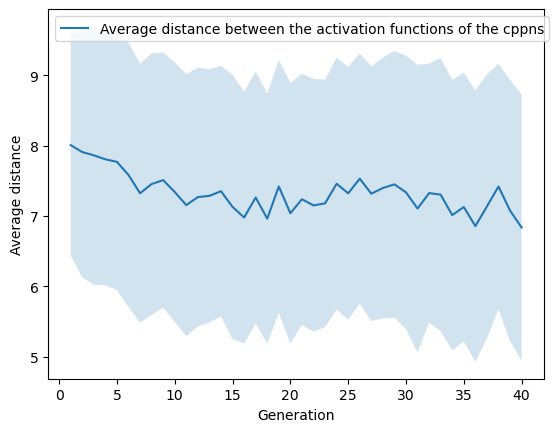

In [ ]:
fig = plt.figure()
plt.plot(diploid_generations, diploid_average_list_distance_functions, label = 'Average distance between the activation functions of the cppns')
plt.fill_between(diploid_generations, np.array(diploid_average_list_distance_functions) - np.array(diploid_std_list_distance_functions), np.array(diploid_average_list_distance_functions) + np.array(diploid_std_list_distance_functions), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')
plt.legend(loc = 'upper left')
plt.show()

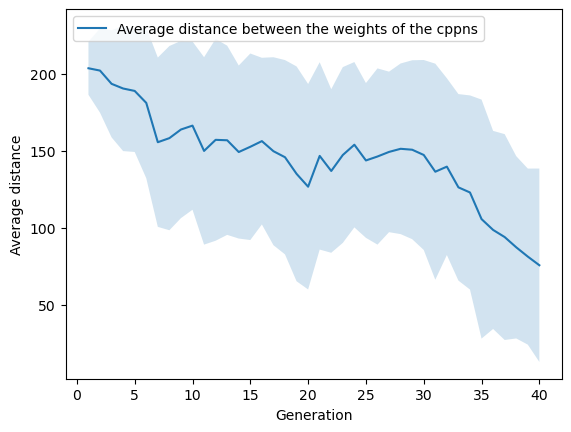

In [ ]:
plt.figure()
plt.plot(diploid_generations, diploid_average_list_distance_weights, label = 'Average distance between the weights of the cppns')
plt.fill_between(diploid_generations, np.array(diploid_average_list_distance_weights) - np.array(diploid_std_list_distance_weights), np.array(diploid_average_list_distance_weights) + np.array(diploid_std_list_distance_weights), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')
plt.legend(loc = 'upper left')
plt.show()

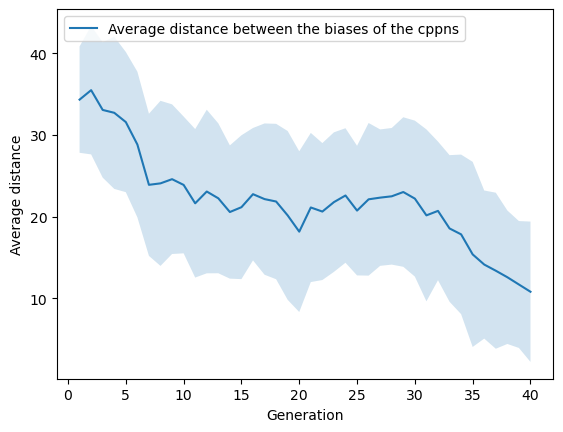

In [ ]:
plt.Figure()
plt.plot(diploid_generations, diploid_average_list_distance_biases, label = 'Average distance between the biases of the cppns')
plt.fill_between(diploid_generations, np.array(diploid_average_list_distance_biases) - np.array(diploid_std_list_distance_biases), np.array(diploid_average_list_distance_biases) + np.array(diploid_std_list_distance_biases), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')    
plt.legend(loc = 'upper left')
plt.show()

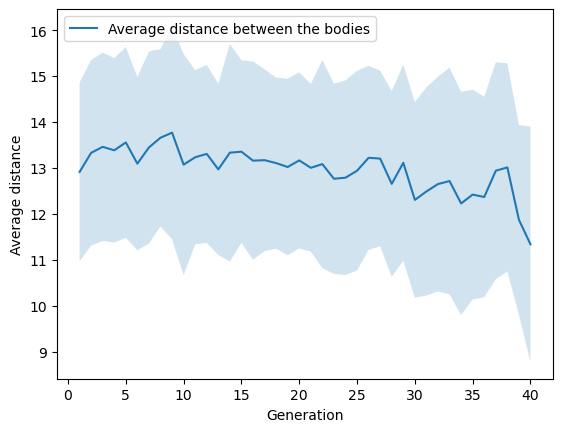

In [ ]:
plt.figure()
plt.plot(diploid_generations, diploid_average_list_distance_bodies, label = 'Average distance between the bodies')
plt.fill_between(diploid_generations, np.array(diploid_average_list_distance_bodies) - np.array(diploid_std_list_distance_bodies), np.array(diploid_average_list_distance_bodies) + np.array(diploid_std_list_distance_bodies), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')
plt.legend(loc = 'upper left')
plt.show()

In [ ]:
plt.figure()
plt.plot(diploid_generations, diploid_average_list_distance_controllers, label = 'Average distance between the controllers')
plt.fill_between(diploid_generations, np.array(diploid_average_list_distance_controllers) - np.array(diploid_std_list_distance_controllers), np.array(diploid_average_list_distance_controllers) + np.array(diploid_std_list_distance_controllers), alpha = 0.2)
plt.xlabel('Generation')
plt.ylabel('Average distance')
plt.legend(loc = 'upper left')
plt.show()

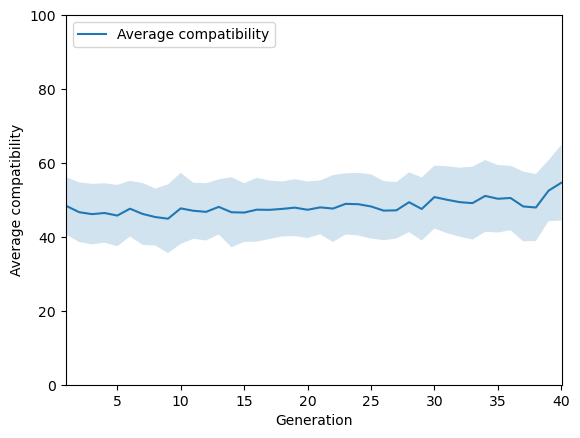

In [ ]:
plt.figure()
plt.plot(diploid_generations, diploid_average_list_compatibility, label = 'Average compatibility')
plt.fill_between(diploid_generations, np.array(diploid_average_list_compatibility) - np.array(diploid_std_list_compatibility), np.array(diploid_average_list_compatibility) + np.array(diploid_std_list_compatibility), alpha = 0.2)
plt.axis([0.95, diploid_generations[-1] + 0.05, 0, 100])
plt.xlabel('Generation')
plt.ylabel('Average compatibility')
plt.legend(loc = 'upper left')
plt.show()

In [ ]:
plt.figure()
plt.plot(diploid_generations, diploid_average_list_normalized_activation_function_distance, label = 'Average normalized distance between the activation functions of the cppns')
plt.plot(diploid_generations, diploid_average_list_normalized_weight_distance, label = 'Average normalized distance between the weights of the cppns')
plt.plot(diploid_generations, diploid_average_list_normalized_bias_distance, label = 'Average normalized distance between the biases of the cppns')
plt.plot(diploid_generations, diploid_average_list_normalized_distance_bodies, label = 'Average normalized distance between the bodies')
plt.plot(diploid_generations, diploid_average_list_normalized_controller_distance, label = 'Average normalized distance between the controllers')
plt.fill_between(diploid_generations, np.array(diploid_average_list_normalized_activation_function_distance) - np.array(diploid_std_list_normalized_activation_function_distance), np.array(diploid_average_list_normalized_activation_function_distance) + np.array(diploid_std_list_normalized_activation_function_distance), alpha = 0.2)
plt.fill_between(diploid_generations, np.array(diploid_average_list_normalized_weight_distance) - np.array(diploid_std_list_normalized_weight_distance), np.array(diploid_average_list_normalized_weight_distance) + np.array(diploid_std_list_normalized_weight_distance), alpha = 0.2)
plt.fill_between(diploid_generations, np.array(diploid_average_list_normalized_bias_distance) - np.array(diploid_std_list_normalized_bias_distance), np.array(diploid_average_list_normalized_bias_distance) + np.array(diploid_std_list_normalized_bias_distance), alpha = 0.2)
plt.fill_between(diploid_generations, np.array(diploid_average_list_normalized_distance_bodies) - np.array(diploid_std_list_normalized_distance_bodies), np.array(diploid_average_list_normalized_distance_bodies) + np.array(diploid_std_list_normalized_distance_bodies), alpha = 0.2)
plt.fill_between(diploid_generations, np.array(diploid_average_list_normalized_controller_distance) - np.array(diploid_std_list_normalized_controller_distance), np.array(diploid_average_list_normalized_controller_distance) + np.array(diploid_std_list_normalized_controller_distance), alpha = 0.2)
plt.axis([0.95, diploid_generations[-1] + 0.05, 0, 1.2])
plt.xlabel('Generations')
plt.ylabel('Normalized distance')
plt.legend(loc = 'upper left')
plt.show()

## Both results to Compare

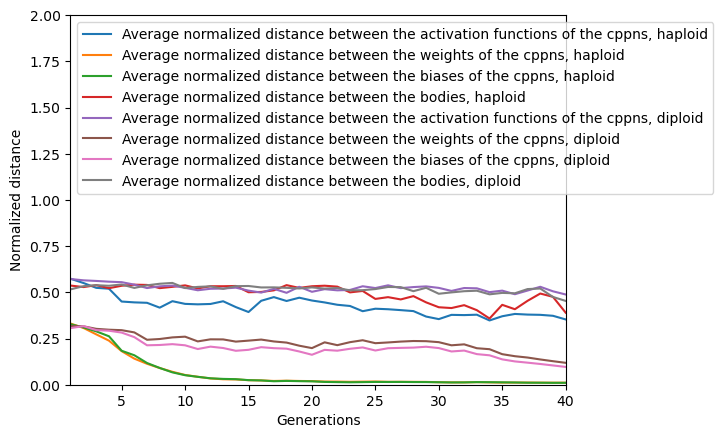

In [ ]:
plt.figure()
plt.plot(generations, average_list_normalized_activation_function_distance, label = 'Average normalized distance between the activation functions of the cppns, haploid')
plt.plot(generations, average_list_normalized_weight_distance, label = 'Average normalized distance between the weights of the cppns, haploid')
plt.plot(generations, average_list_normalized_bias_distance, label = 'Average normalized distance between the biases of the cppns, haploid')
plt.plot(generations, average_list_normalized_distance_bodies, label = 'Average normalized distance between the bodies, haploid')
plt.plot(diploid_generations, diploid_average_list_normalized_activation_function_distance, label = 'Average normalized distance between the activation functions of the cppns, diploid')
plt.plot(diploid_generations, diploid_average_list_normalized_weight_distance, label = 'Average normalized distance between the weights of the cppns, diploid')
plt.plot(diploid_generations, diploid_average_list_normalized_bias_distance, label = 'Average normalized distance between the biases of the cppns, diploid')
plt.plot(diploid_generations, diploid_average_list_normalized_distance_bodies, label = 'Average normalized distance between the bodies, diploid')
plt.axis([0.95, generations[-1] + 0.05, 0, 2])
plt.xlabel('Generations')
plt.ylabel('Normalized distance')
plt.legend(loc = 'upper left')
plt.show()

## Controllers to Compare

In [ ]:
plt.figure()
plt.plot(generations, average_list_normalized_controller_distance, label = 'Average normalized distance between the controllers, haploid')
plt.plot(diploid_generations, diploid_average_list_normalized_controller_distance, label = 'Average normalized distance between the controllers, diploid')
plt.axis([0.95, generations[-1] + 0.05, 0, 1.2])
plt.xlabel('Generations')
plt.ylabel('Normalized distance')
plt.legend(loc = 'upper left')
plt.show()